**PART 1**

Strategy - Buy Nifty50 future if 10-day SMA crosses above the 20-day SMA and sell if 10-day SMA crosses below the 20-day SMA

**WITHOUT OOP**

In [2]:
!pip install quantstats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 6.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import quantstats as qs

In [4]:
start1 = dt.date(2022, 1, 1)
end1 = dt.date(2025, 12, 31)

In [6]:
ticker = "^NSEI"

df = yf.download(tickers=ticker, start=start1, end=end1)

/tmp/ipykernel_13384/948279142.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers=ticker, start=start1, end=end1)
[*********************100%***********************]  1 of 1 completed


In [7]:
df1 = df.copy()
df1

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2022-01-03,17625.699219,17646.650391,17383.300781,17387.150391,200500
2022-01-04,17805.250000,17827.599609,17593.550781,17681.400391,247400
2022-01-05,17925.250000,17944.699219,17748.849609,17820.099609,251500
2022-01-06,17745.900391,17797.949219,17655.550781,17768.500000,236500
2022-01-07,17812.699219,17905.000000,17704.550781,17797.599609,239300
...,...,...,...,...,...
2025-12-23,26177.150391,26233.550781,26119.050781,26205.199219,216600
2025-12-24,26142.099609,26236.400391,26123.000000,26170.650391,188800


In [8]:
df1 = df1.droplevel(1,axis=1)
df1

Price,Close,High,Low,Open,Volume
Date,,,,,
2022-01-03,17625.699219,17646.650391,17383.300781,17387.150391,200500
2022-01-04,17805.250000,17827.599609,17593.550781,17681.400391,247400
2022-01-05,17925.250000,17944.699219,17748.849609,17820.099609,251500
2022-01-06,17745.900391,17797.949219,17655.550781,17768.500000,236500
2022-01-07,17812.699219,17905.000000,17704.550781,17797.599609,239300
...,...,...,...,...,...
2025-12-23,26177.150391,26233.550781,26119.050781,26205.199219,216600
2025-12-24,26142.099609,26236.400391,26123.000000,26170.650391,188800
2025-12-26,26042.300781,26144.199219,26008.599609,26121.250000,142200


In [9]:
# Setting the short and long period SMAs. Using the variables and columns such that they can be re-used even if the periods are changed

s = 10
l = 20

df1['short_sma'] = df1['Close'].rolling(window=s,center=False).mean()
df1['long_sma'] = df1['Close'].rolling(window=l,center=False).mean()

df1['prev_short_sma'] = df1['short_sma'].shift(1)
df1['prev_long_sma'] = df1['long_sma'].shift(1)

df1

Price,Close,High,Low,Open,Volume,short_sma,long_sma,prev_short_sma,prev_long_sma
Date,,,,,,,,,
2022-01-03,17625.699219,17646.650391,17383.300781,17387.150391,200500,NaN,NaN,NaN,NaN
2022-01-04,17805.250000,17827.599609,17593.550781,17681.400391,247400,NaN,NaN,NaN,NaN
2022-01-05,17925.250000,17944.699219,17748.849609,17820.099609,251500,NaN,NaN,NaN,NaN
2022-01-06,17745.900391,17797.949219,17655.550781,17768.500000,236500,NaN,NaN,NaN,NaN
2022-01-07,17812.699219,17905.000000,17704.550781,17797.599609,239300,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2025-12-23,26177.150391,26233.550781,26119.050781,26205.199219,216600,25954.095313,26018.955176,25920.345313,26004.337695
2025-12-24,26142.099609,26236.400391,26123.000000,26170.650391,188800,25992.505273,26015.795117,25954.095313,26018.955176
2025-12-26,26042.300781,26144.199219,26008.599609,26121.250000,142200,26006.880273,26007.132617,25992.505273,26015.795117


In [12]:
df1['signal'] = np.where((df1['short_sma']>df1['long_sma']) & (df1['prev_short_sma']<df1['prev_long_sma']),1,0)

df1['signal'] = np.where((df1['short_sma']<df1['long_sma']) & (df1['prev_short_sma']>df1['prev_long_sma']),-1,df1['signal'])

df1['signal'].value_counts()

,count
signal,
0,936
1,26
-1,25


In [14]:
df1['position'] = df1['signal'].replace(0).ffill()

/tmp/ipykernel_13384/3447956107.py:1: FutureWarning: Series.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  df1['position'] = df1['signal'].replace(0).ffill()


In [17]:
df1['bnh_returns'] = np.log(df1['Close'] / df1['Close'].shift(1))

df1['strategy_returns'] = df1['bnh_returns'] * df1['position'].shift(1)

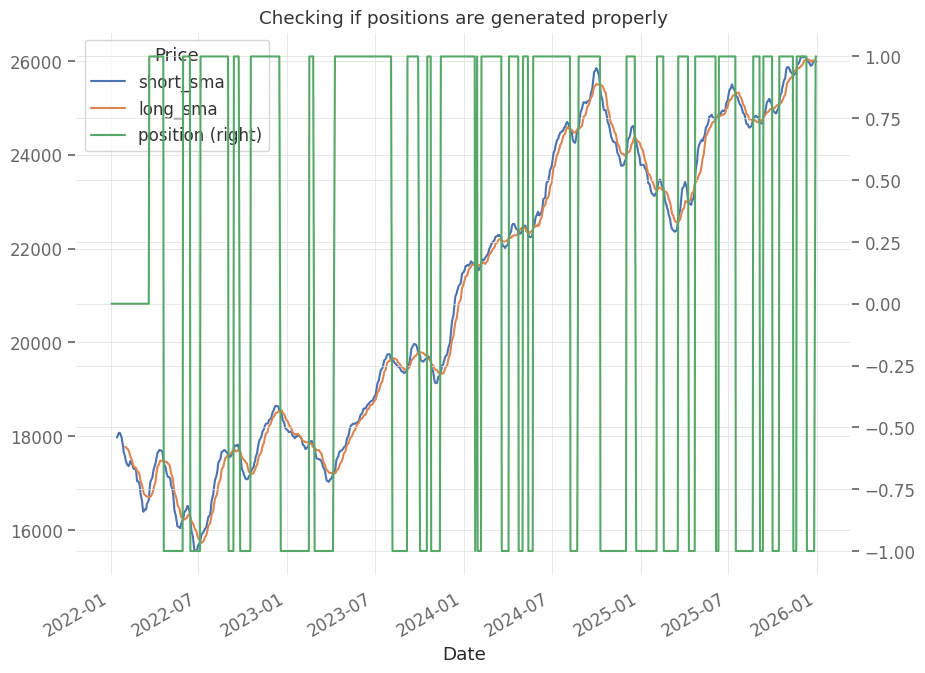

In [18]:
df1[['short_sma','long_sma','position']].plot(grid=True, secondary_y='position', figsize=(10,8))
plt.title('Checking if positions are generated properly')
plt.show()

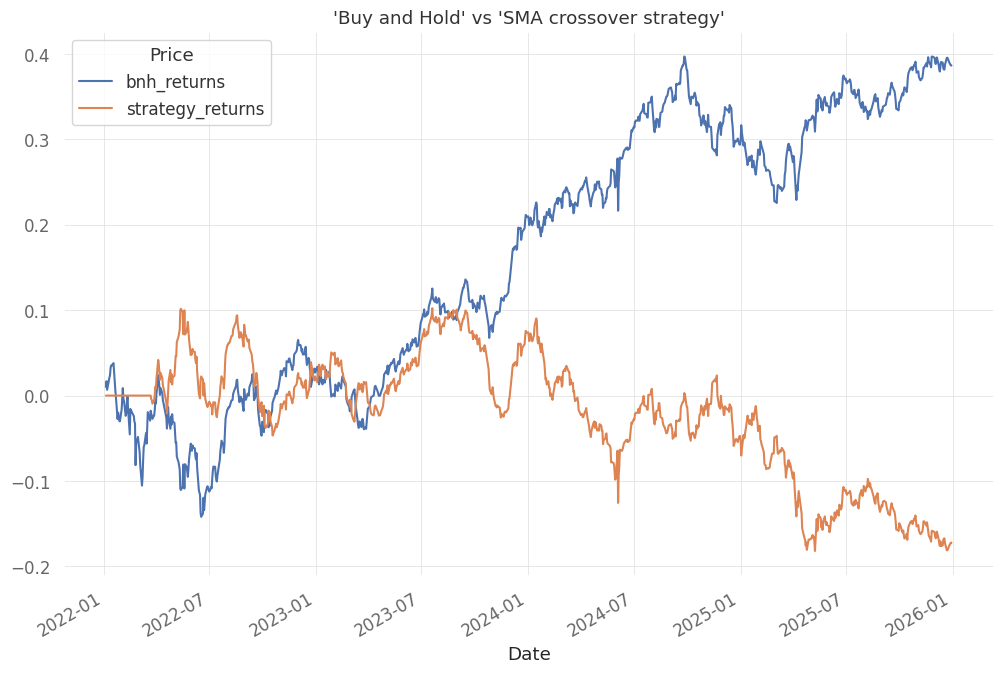

In [19]:
df1[['bnh_returns','strategy_returns']].cumsum().plot(grid=True, secondary_y='position', figsize=(12,8))
plt.title("'Buy and Hold' vs 'SMA crossover strategy'")
plt.show()

                 Parameters
----------------------------------------
Periods/Year                         252
Risk-Free Rate                     0.0%
Compounded                           Yes

[Performance Metrics]


Parameter       Value
--------------  -------
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Strategy
-------------------  ----------
Start Period         2022-01-04
End Period           2025-12-30
Risk-Free Rate       0.0%
Time in Market       95.0%

Cumulative Return    -18.35%
CAGR﹪               -5.05%

Sharpe               -0.35
Prob. Sharpe Ratio   24.17%
Sortino              -0.48
Sortino/√2           -0.34
Omega                0.94

Max Drawdown         -26.74%
Max DD Date          2025-12-23
Max DD Period Start  2022-05-16
Max DD Period End    2025-12-30
Longest DD Days      1325

Gain/Pain Ratio      -0.06
Gain/Pain (1M)       -0.22

Payoff Ratio         0.9
Profit Factor        0.94
Common Sense Ratio   0.8

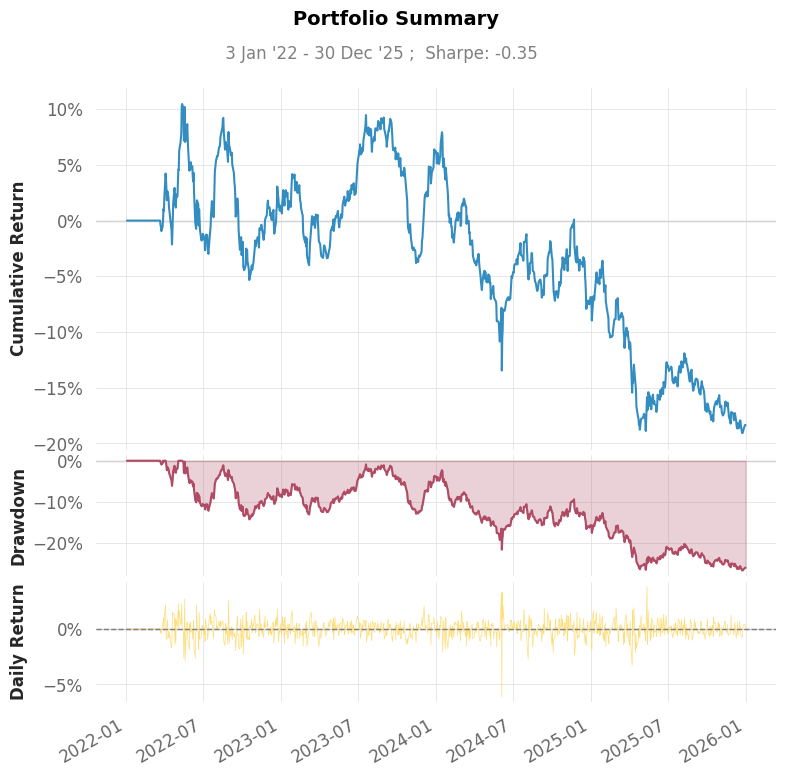

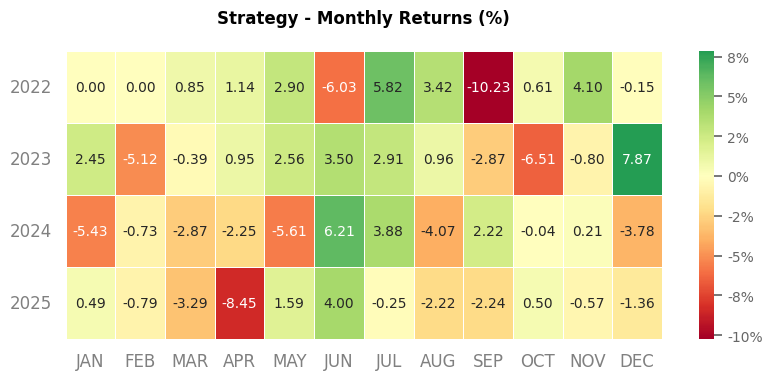

In [20]:
qs.reports.basic(df1['strategy_returns'])

**PART 2**

Strategy - Buy Nifty50 future if 10-day SMA crosses above the 20-day SMA and sell if 10-day SMA crosses below the 20-day SMA

**USING OOP**

In [28]:
# Creating one class to handle all the tasks

class BacktestingCrossover:

  def __init__(self, ticker, start_date, end_date, ma_short, ma_long):
    self.ticker = ticker
    self.start_date = start_date
    self.end_date = end_date
    self.ma_short = ma_short
    self.ma_long = ma_long

    self.fetch_data()
    self.indicators()
    self.signals()
    self.positions()
    self.returns()

  def fetch_data(self):
    self.df = yf.download(tickers=self.ticker, start=self.start_date, end=self.end_date)
    self.df = self.df.droplevel(1,axis=1)

  def indicators(self):
    self.df['ma_short'] = self.df['Close'].rolling(window=self.ma_short, center=False).mean()
    self.df['ma_long'] = self.df['Close'].rolling(window=self.ma_long, center=False).mean()
    self.df['prev_ma_short'] = self.df['ma_short'].shift(1)
    self.df['prev_ma_long'] = self.df['ma_long'].shift(1)
    self.df.dropna(inplace=True)

  def signals(self):
    self.df['signal'] = np.where((self.df['ma_short']>self.df['ma_long']) & (self.df['prev_ma_short']>self.df['prev_ma_long']),1,0)
    self.df['signal'] = np.where((self.df['ma_short']<self.df['ma_long']) & (self.df['prev_ma_short']<self.df['prev_ma_long']),-1,self.df['signal'])

  def positions(self):
    self.df['position'] = self.df['signal'].replace(to_replace=0, method='ffill')

  def returns(self):
    self.df['bnh_returns'] = np.log(self.df['Close'] / self.df['Close'].shift(1))
    self.df['strategy_returns'] = self.df['position'].shift(1) * self.df['bnh_returns']
    print('Total Returns: ', np.round(self.df['strategy_returns'].cumsum()[-1],2))
    return self.df['strategy_returns'].cumsum()[-1]

  def analysis(self):
    self.df[['ma_short','ma_long','position']].plot(grid=True, secondary_y='position', figsize=(12,8))
    plt.title('Checking if positions are generated properly')
    plt.show()

    self.df[['bnh_returns','strategy_returns']].cumsum().plot(grid=True, secondary_y='position', figsize=(12,8))
    plt.title("'Buy and Hold' vs 'SMA crossover strategy'")
    plt.show()

    qs.reports.basic(self.df['strategy_returns'])

In [32]:
# Test scenario 1

start_date = dt.datetime(2022, 1, 1).date()
end_date = dt.datetime(2025, 12, 31).date()

nifty_10_20 = BacktestingCrossover('^NSEI',start_date, end_date, 10, 20)

/tmp/ipykernel_13384/85026078.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.df = yf.download(tickers=self.ticker, start=self.start_date, end=self.end_date)
[*********************100%***********************]  1 of 1 completed

Total Returns:  -0.06



/tmp/ipykernel_13384/85026078.py:34: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  self.df['position'] = self.df['signal'].replace(to_replace=0, method='ffill')
/tmp/ipykernel_13384/85026078.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('Total Returns: ', np.round(self.df['strategy_returns'].cumsum()[-1],2))
/tmp/ipykernel_13384/85026078.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return self.df['strategy_returns'].cumsum()[-1]


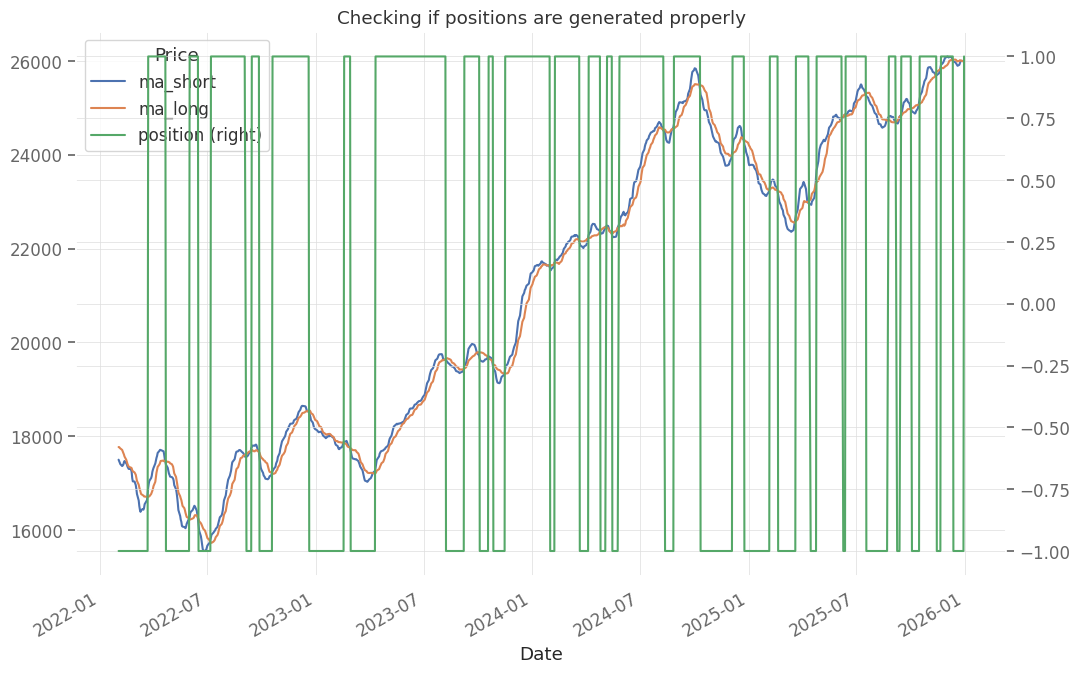

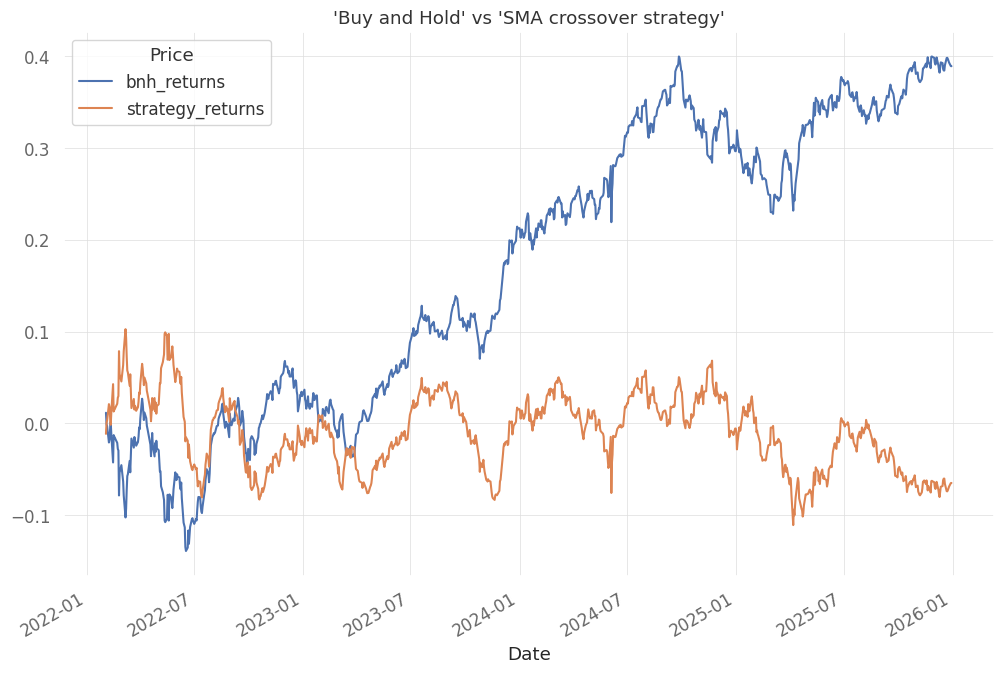

                 Parameters
----------------------------------------
Periods/Year                         252
Risk-Free Rate                     0.0%
Compounded                           Yes

[Performance Metrics]


Parameter       Value
--------------  -------
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Strategy
-------------------  ----------
Start Period         2022-02-02
End Period           2025-12-30
Risk-Free Rate       0.0%
Time in Market       100.0%

Cumulative Return    -9.51%
CAGR﹪               -2.57%

Sharpe               -0.13
Prob. Sharpe Ratio   40.28%
Sortino              -0.17
Sortino/√2           -0.12
Omega                0.98

Max Drawdown         -21.4%
Max DD Date          2025-04-07
Max DD Period Start  2022-03-08
Max DD Period End    2025-12-30
Longest DD Days      1394

Gain/Pain Ratio      -0.02
Gain/Pain (1M)       -0.09

Payoff Ratio         0.92
Profit Factor        0.98
Common Sense Ratio   0.9

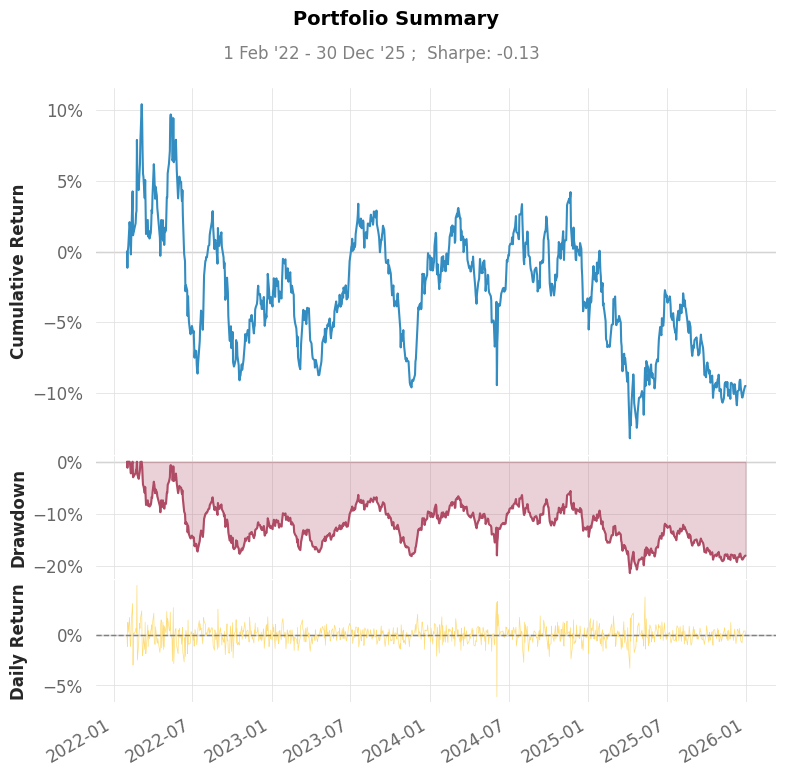

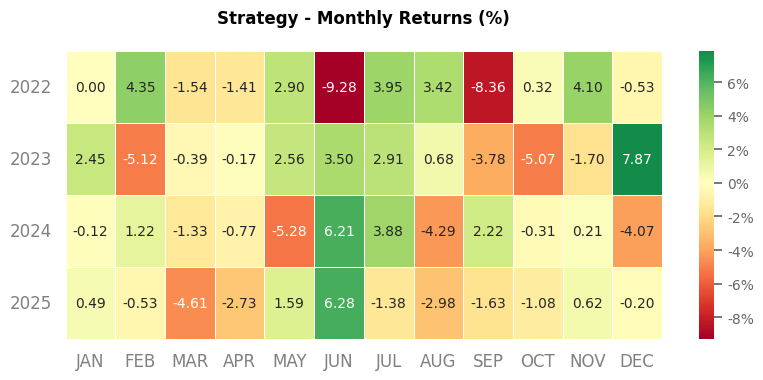

In [33]:
nifty_10_20.analysis()

In [34]:
# Test scenario 2

nifty_5_20 = BacktestingCrossover('^NSEI',start_date,end_date,5,20)

/tmp/ipykernel_13384/85026078.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.df = yf.download(tickers=self.ticker, start=self.start_date, end=self.end_date)
[*********************100%***********************]  1 of 1 completed

Total Returns:  -0.05



/tmp/ipykernel_13384/85026078.py:34: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  self.df['position'] = self.df['signal'].replace(to_replace=0, method='ffill')
/tmp/ipykernel_13384/85026078.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('Total Returns: ', np.round(self.df['strategy_returns'].cumsum()[-1],2))
/tmp/ipykernel_13384/85026078.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return self.df['strategy_returns'].cumsum()[-1]


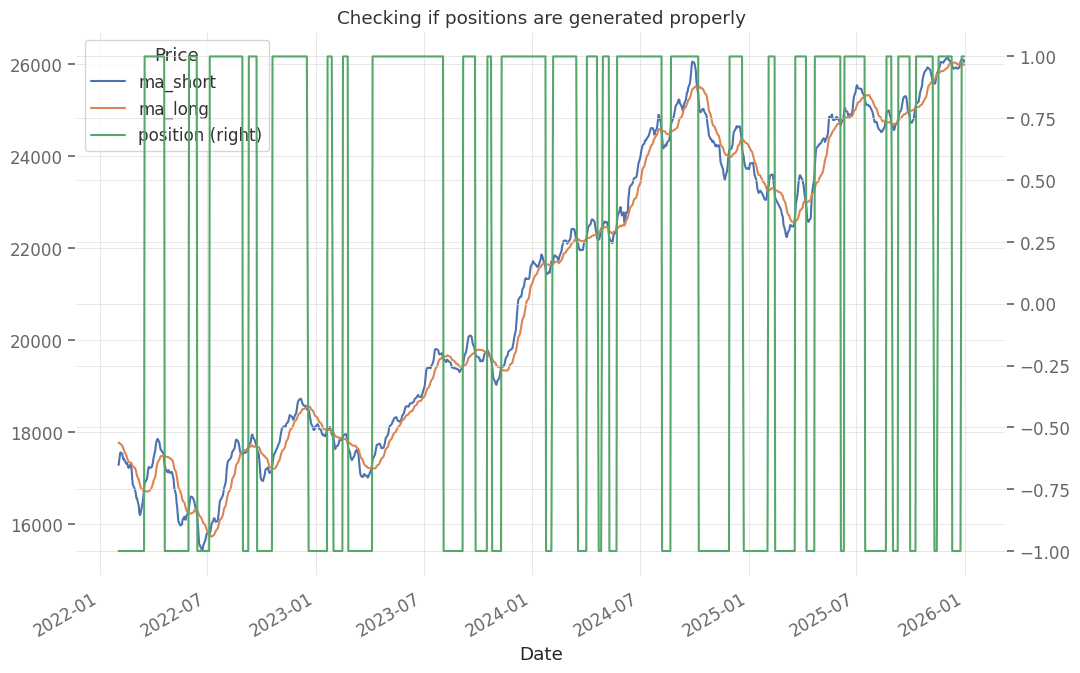

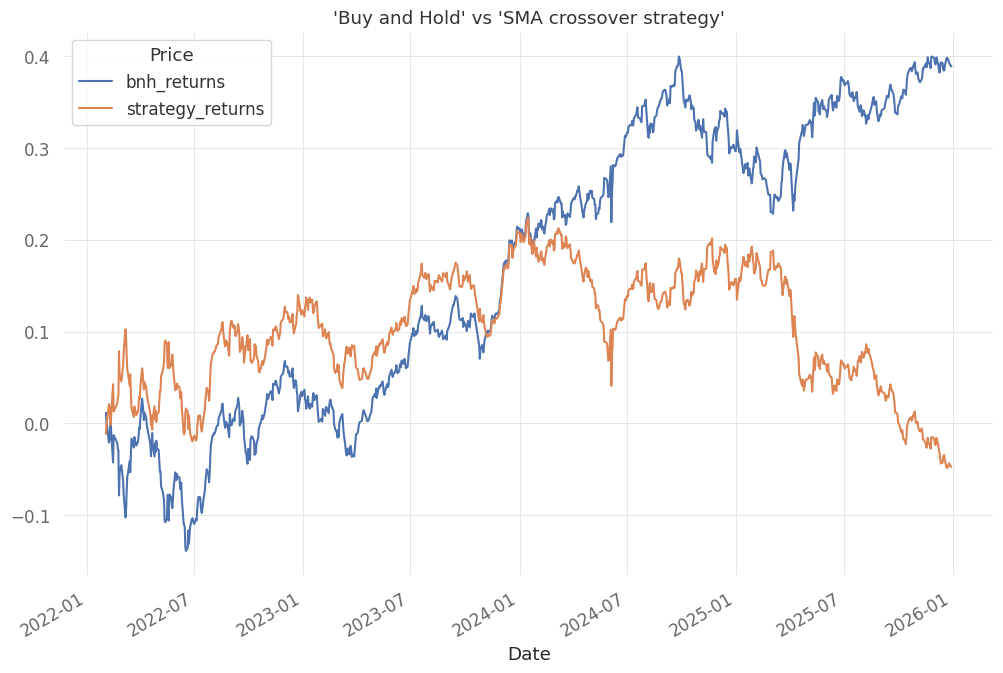

                 Parameters
----------------------------------------
Periods/Year                         252
Risk-Free Rate                     0.0%
Compounded                           Yes

[Performance Metrics]


Parameter       Value
--------------  -------
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Strategy
-------------------  ----------
Start Period         2022-02-02
End Period           2025-12-30
Risk-Free Rate       0.0%
Time in Market       100.0%

Cumulative Return    -7.92%
CAGR﹪               -2.13%

Sharpe               -0.09
Prob. Sharpe Ratio   42.86%
Sortino              -0.13
Sortino/√2           -0.09
Omega                0.98

Max Drawdown         -25.12%
Max DD Date          2025-12-23
Max DD Period Start  2024-01-16
Max DD Period End    2025-12-30
Longest DD Days      715

Gain/Pain Ratio      -0.02
Gain/Pain (1M)       -0.07

Payoff Ratio         0.92
Profit Factor        0.98
Common Sense Ratio   0.8

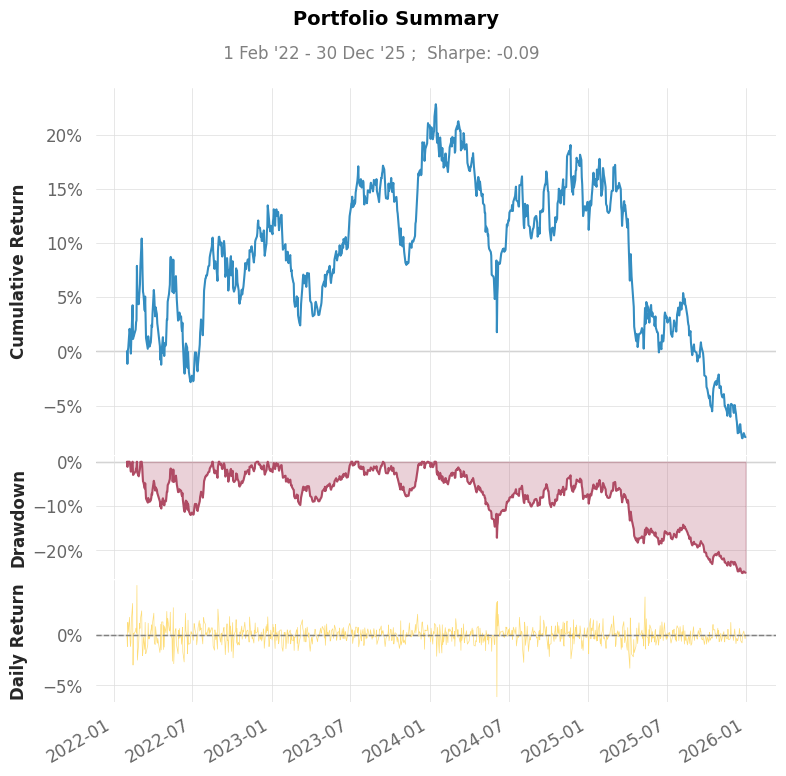

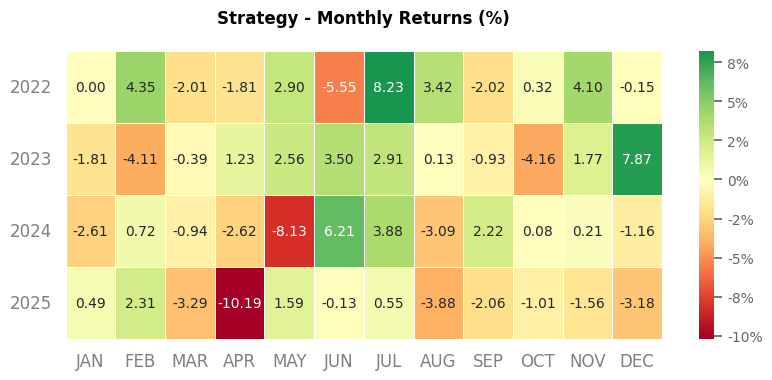

In [35]:
nifty_5_20.analysis()

In [36]:
# Test Scenario 3

nifty_20_50 = BacktestingCrossover('^NSEI',start_date,end_date,20,50)

/tmp/ipykernel_13384/85026078.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.df = yf.download(tickers=self.ticker, start=self.start_date, end=self.end_date)
[*********************100%***********************]  1 of 1 completed


Total Returns:  0.07


/tmp/ipykernel_13384/85026078.py:34: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  self.df['position'] = self.df['signal'].replace(to_replace=0, method='ffill')
/tmp/ipykernel_13384/85026078.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('Total Returns: ', np.round(self.df['strategy_returns'].cumsum()[-1],2))
/tmp/ipykernel_13384/85026078.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return self.df['strategy_returns'].cumsum()[-1]


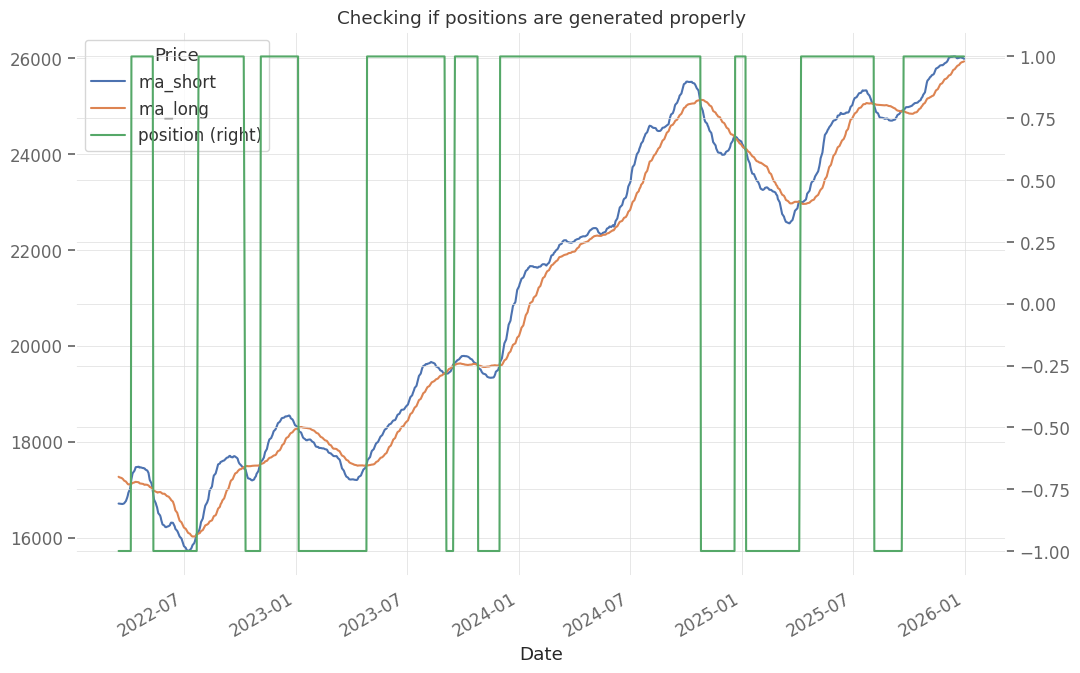

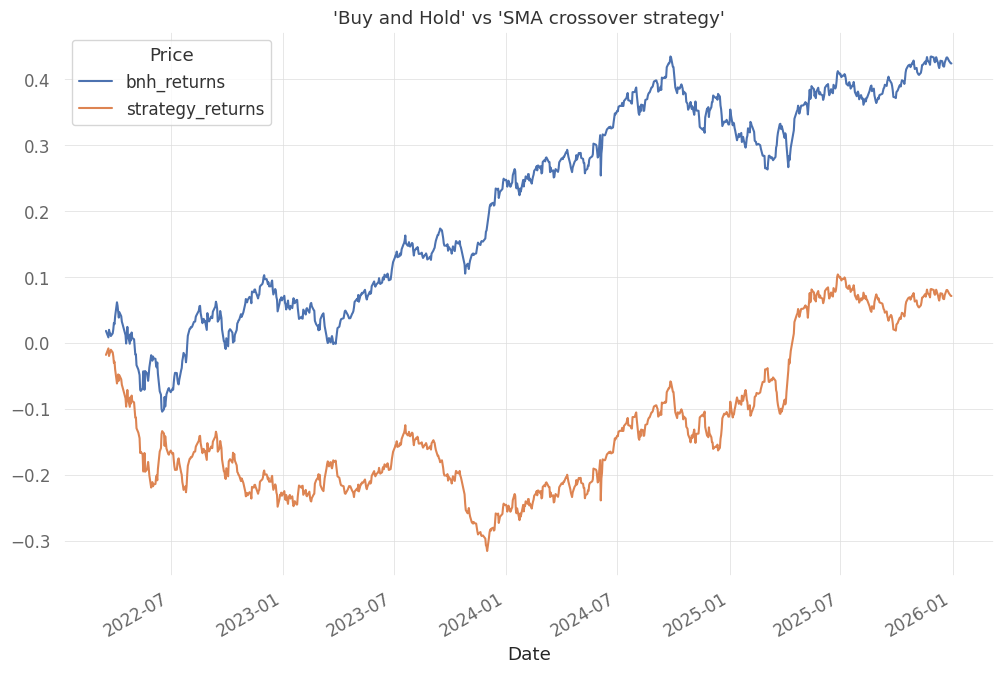

                 Parameters
----------------------------------------
Periods/Year                         252
Risk-Free Rate                     0.0%
Compounded                           Yes

[Performance Metrics]


Parameter       Value
--------------  -------
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Strategy
-------------------  ----------
Start Period         2022-03-17
End Period           2025-12-30
Risk-Free Rate       0.0%
Time in Market       100.0%

Cumulative Return    4.13%
CAGR﹪               1.09%

Sharpe               0.15
Prob. Sharpe Ratio   61.28%
Sortino              0.21
Sortino/√2           0.15
Omega                1.03

Max Drawdown         -28.06%
Max DD Date          2023-12-01
Max DD Period Start  2022-03-17
Max DD Period End    2025-04-16
Longest DD Days      1127

Gain/Pain Ratio      0.03
Gain/Pain (1M)       0.09

Payoff Ratio         0.93
Profit Factor        1.03
Common Sense Ratio   1.08
CPC 

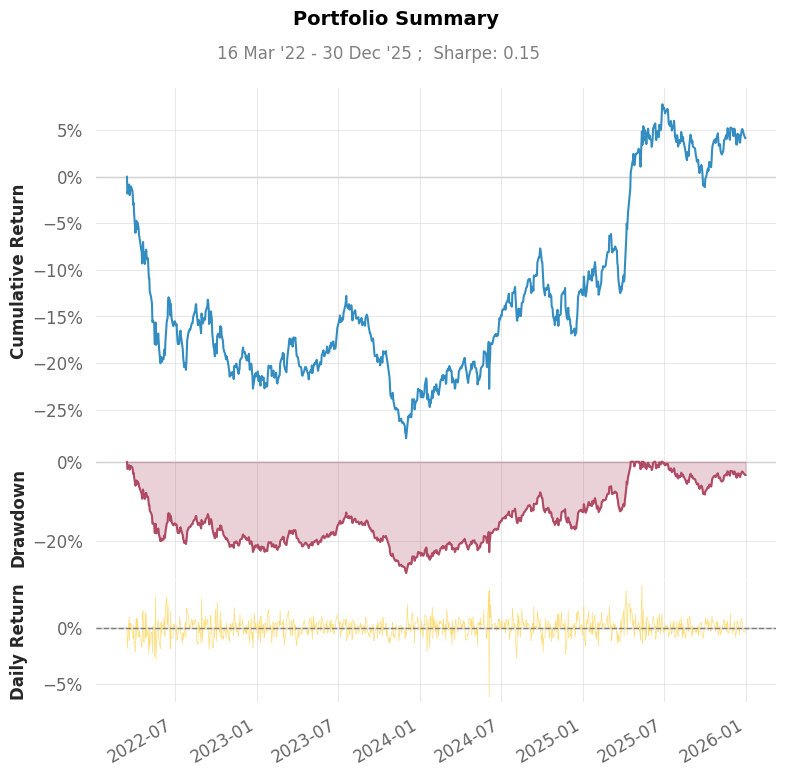

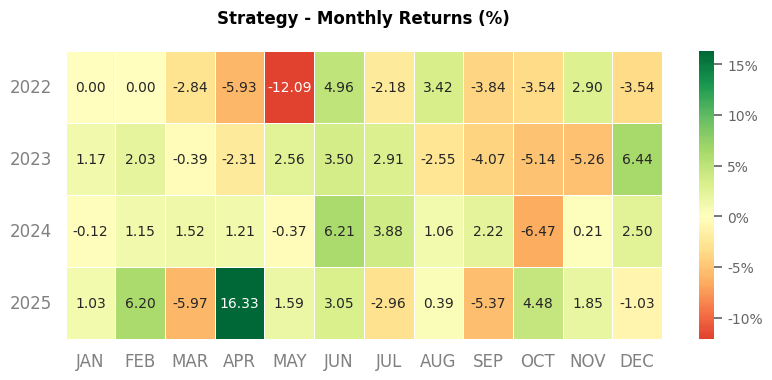

In [37]:
nifty_20_50.analysis()